In [78]:
import jax
import sys
sys.path.insert(0, '/Users/mjablons/code/spice/src')

from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.models.spots import add_spots, add_spot
from spice.plots import plot_3D
from spice.spectrum import simulate_observed_flux
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cmasher as cmr
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import astro_emulators_toolkit as aemu

# Spotted star from Kochukhov (2017)

In [79]:
import zarr
o = zarr.open_group('/Users/mjablons/code/spice/data/fe_nlte_paper.zarr')
o.tree()

/Users/mjablons/anaconda3/envs/astro/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at 'index.parquet' not found in consolidated metadata. is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


/
└── fe_nlte_paper.zarr
    ├── continuum (26720, 2001) float32
    ├── flux (26720, 2001) float32
    ├── global_index (26720,) int64
    ├── model_id (26720,) uint64
    ├── param_names (15,) <U32
    ├── params (26720, 15) float32
    ├── physics_hash (1,) <U72
    ├── provenance
    │   ├── atmosphere_manifest.json (1,) StringDType()
    │   ├── canonical_config.yaml (1,) StringDType()
    │   ├── environment.txt (1,) StringDType()
    │   ├── input_config.json (1,) StringDType()
    │   ├── linelist_manifest.json (1,) StringDType()
    │   ├── software_manifest.json (1,) StringDType()
    │   └── synthesis_config.yaml (1,) StringDType()
    ├── schema_version (1,) <U16
    └── wavelength (2001,) float32

In [80]:
line_interp = IntensityLazyZarrInterpolator(
    '/Users/mjablons/code/spice/data/fe_nlte_paper.zarr/fe_nlte_paper.zarr',
    params=['teff', 'logg', 'feh', "mu", 'vmicro'],
    sparse=True)
print('[Fe/H] grid range:', float(line_interp.min_stellar_parameters[2]), 'to', float(line_interp.max_stellar_parameters[2]))

[spice] Building sparse grid index...
[spice] Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 1.0 s
[Fe/H] grid range: -5.0 to 0.0


In [81]:
m = IcosphereModel.construct(10000, 1.9, 1.5,
                             line_interp.to_parameters({'teff':8000, 'logg':4.0, 'feh':-4.0, 'vmicro':1.0}),
                             line_interp.stellar_parameter_names, override_log_g=False)


[spice] IcosphereModel constructed in 0.6 s


In [82]:
no_spots = simulate_observed_flux(line_interp.intensity, m, jnp.log10(vws))

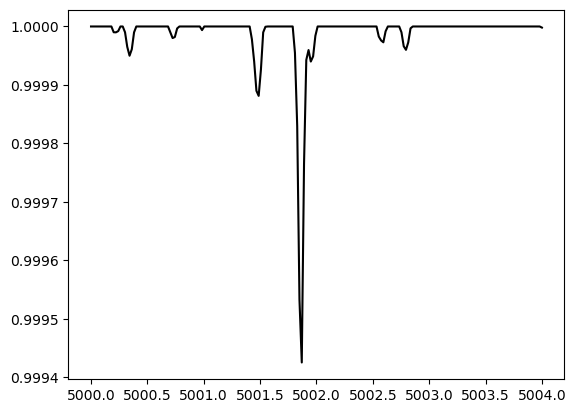

In [83]:
plt.plot(vws, no_spots[:, 0] / no_spots[:, 1], color='black')

In [84]:
incl = 60.
# Calculate v_e from v_e*sin(incl) = 40 km/s
v_e_sin_i = 40.  # km/s
incl_rad = np.deg2rad(incl)
v_e = v_e_sin_i / np.sin(incl_rad)
print(f"v_e = {v_e:.2f} km/s (with v_e*sin(i) = {v_e_sin_i} km/s at inclination {incl}°)")

v_e = 46.19 km/s (with v_e*sin(i) = 40.0 km/s at inclination 60.0°)


In [85]:
from spice.models.mesh_view import get_mesh_view
from spice.models.utils import inclination_to_los_axis, lat_to_theta, lon_to_phi, velocity_to_period

period_seconds = velocity_to_period(v_e, m.radius)
timestamps = jnp.linspace(0, period_seconds, 25)

# Convert inclination to LOS vector
mt = get_mesh_view(add_rotation(m, v_e), los_vector=inclination_to_los_axis(incl))

SPOT_RADIUS = 25.

ms = add_spots(mt,
               spot_center_thetas=jnp.array([lat_to_theta(lat_deg) for lat_deg in [-30, 0, 30, 60]]),
               spot_center_phis=jnp.array([lon_to_phi(lon_deg) for lon_deg in [-90, 0, 90, 180]]),
               spot_radii=jnp.array(4*[SPOT_RADIUS]),
               parameter_deltas=jnp.array(4*[2.5]),
               parameter_indices=jnp.array(4*[2]),
               smoothness=jnp.array(4*[0.5]))

ms_min30 = add_spot(mt,
               spot_center_theta=lat_to_theta(-30),
               spot_center_phi=lon_to_phi(-90),
               spot_radius=SPOT_RADIUS,
               parameter_delta=2.5,
               parameter_index=2,
               smoothness=0.5)

ms_0 = add_spot(mt,
               spot_center_theta=lat_to_theta(0),
               spot_center_phi=lon_to_phi(0),
               spot_radius=SPOT_RADIUS,
               parameter_delta=2.5,
               parameter_index=2,
               smoothness=0.5)

ms_30 = add_spot(mt,
               spot_center_theta=lat_to_theta(30),
               spot_center_phi=lon_to_phi(90),
               spot_radius=SPOT_RADIUS,
               parameter_delta=2.5,
               parameter_index=2,
               smoothness=0.5)
ms_60 = add_spot(mt,
               spot_center_theta=lat_to_theta(60),
               spot_center_phi=lon_to_phi(180),
               spot_radius=SPOT_RADIUS,
               parameter_delta=2.5,
               parameter_index=2,
               smoothness=0.5)


In [86]:
from tqdm import tqdm

In [87]:
mts = [evaluate_rotation(ms, t) for t in tqdm(timestamps)]
mts_min30 = [evaluate_rotation(ms_min30, t) for t in tqdm(timestamps)]
mts_0 = [evaluate_rotation(ms_0, t) for t in tqdm(timestamps)]
mts_30 = [evaluate_rotation(ms_30, t) for t in tqdm(timestamps)]
mts_60 = [evaluate_rotation(ms_60, t) for t in tqdm(timestamps)]

100%|██████████| 25/25 [00:00<00:00, 64.59it/s]


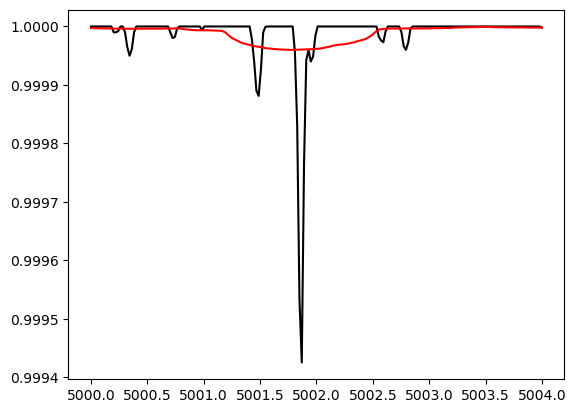

In [88]:
rotated_no_spots = evaluate_rotation(mt, 0.0)
rotated_no_spots_flux = simulate_observed_flux(line_interp.intensity, rotated_no_spots, jnp.log10(vws))
plt.plot(vws, no_spots[:, 0] / no_spots[:, 1], color='black')
plt.plot(vws, rotated_no_spots_flux[:, 0] / rotated_no_spots_flux[:, 1], color='red')

/Users/mjablons/anaconda3/envs/astro/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


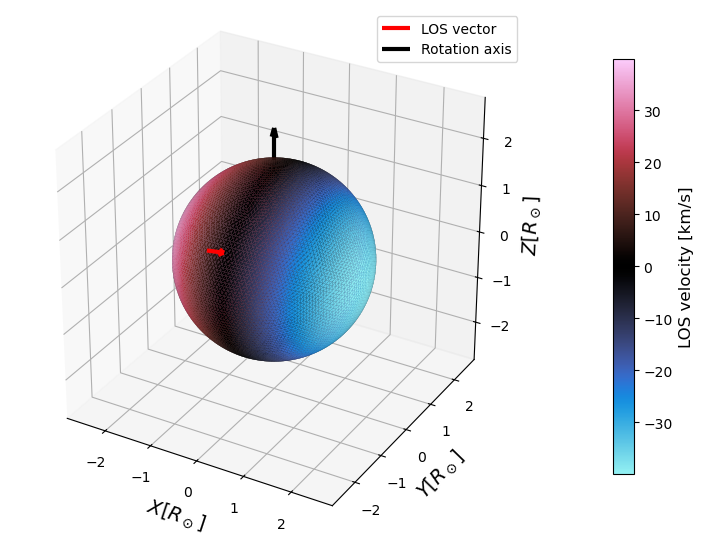

In [89]:
fig, _ = plot_3D(mts[0], 'los_velocities');

/Users/mjablons/anaconda3/envs/astro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


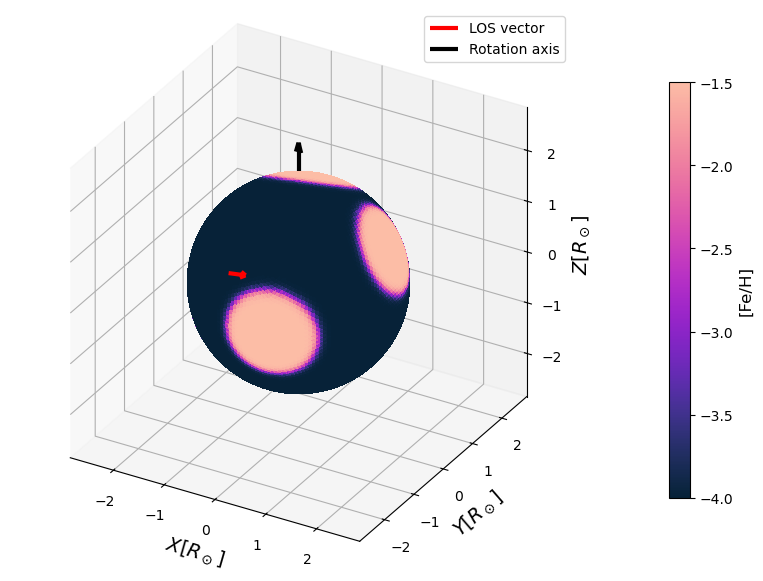

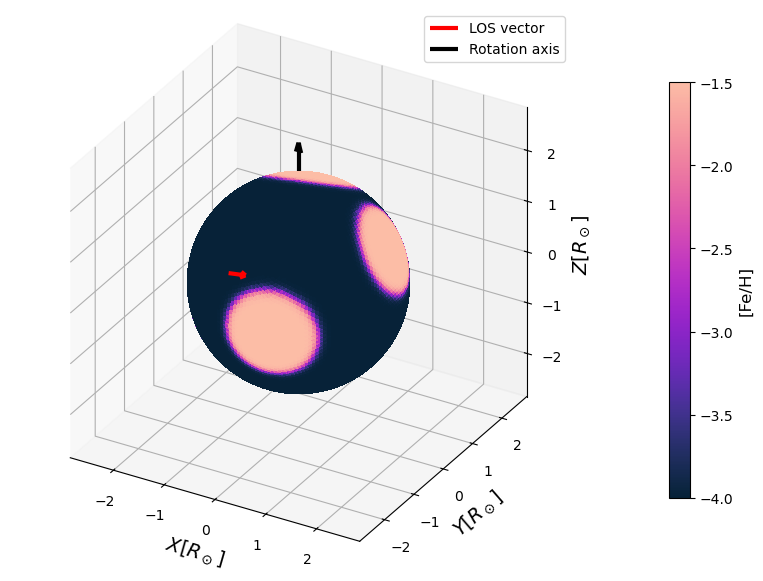

In [90]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import (
    DEFAULT_CMAP,
    _mesh_center,
    _set_axes_centered,
    _single_mesh_arrow_vectors,
)

mesh = mts[5]
fe_h = np.asarray(mesh.parameters[:, 2])
cmap = DEFAULT_CMAP
vmin, vmax = fe_h.min(), fe_h.max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig_fe = plt.figure(figsize=(10, 12))
ax_fe = fig_fe.add_subplot(projection="3d")
ax_fe.set_proj_type("ortho")

face_colors = mpl.colormaps[cmap](norm(fe_h))
ax_fe.add_collection(art3d.Poly3DCollection(
    mesh.mesh_elements,
    facecolors=face_colors,
    edgecolor="none",
    linewidths=0,
    antialiased=False,
))

center = _mesh_center(mesh)
axes_lim = 1.5 * float(mesh.radius)
_set_axes_centered(ax_fe, center, axes_lim)
ax_fe.set_xlabel("$X [R_\\odot]$", fontsize=14)
ax_fe.set_ylabel("$Y [R_\\odot]$", fontsize=14)
ax_fe.set_zlabel("$Z [R_\\odot]$", fontsize=14)
ax_fe.set_box_aspect((1, 1, 1))

los_start, los_vec, rotation_start, rotation_vec = _single_mesh_arrow_vectors(mesh)
ax_fe.quiver(*los_start, *los_vec, color="red", linewidth=3.0, label="LOS vector")
ax_fe.quiver(*rotation_start, *rotation_vec, color="black", linewidth=3.0, label="Rotation axis")
ax_fe.legend()

ax_fe.view_init(elev=30, azim=-60)

mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = fig_fe.colorbar(mappable, shrink=0.45, pad=0.125, ax=ax_fe)
cbar.set_label("[Fe/H]", fontsize=12)

fig_fe

In [91]:
fig_fe.savefig("kochukov_2017.pdf", bbox_inches="tight")

/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_10656/2020729399.py:1: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_fe.savefig("kochukov_2017.pdf", bbox_inches="tight")


In [92]:
vws = jnp.linspace(5000, 5004, 200)
spec = []
spec_min30 = []
spec_0 = []
spec_30 = []
spec_60 = []

for i in tqdm(range(len(mts))):
    spec.append(simulate_observed_flux(line_interp.intensity, mts[i], jnp.log10(vws)))
    spec_min30.append(simulate_observed_flux(line_interp.intensity, mts_min30[i], jnp.log10(vws)))
    spec_0.append(simulate_observed_flux(line_interp.intensity, mts_0[i], jnp.log10(vws)))
    spec_30.append(simulate_observed_flux(line_interp.intensity, mts_30[i], jnp.log10(vws)))
    spec_60.append(simulate_observed_flux(line_interp.intensity, mts_60[i], jnp.log10(vws)))

spec_flux = np.stack([np.asarray(s[:, 0]) for s in spec])
pairwise = [np.max(np.abs(spec_flux[i] - spec_flux[j]))
            for i in range(len(spec)) for j in range(i + 1, len(spec))]
print(f'max pairwise flux difference across phases: {max(pairwise):.6e}')
print(f'los_velocities std (phase 0 / mid / last):',
      [float(np.std(np.asarray(mts[k].los_velocities))) for k in (0, len(mts)//2, -1)])


100%|██████████| 25/25 [03:12<00:00,  7.72s/it]

max pairwise flux difference across phases: 4.486689e-12
los_velocities std (phase 0 / mid / last): [23.08987808227539, 23.08987808227539, 23.08987808227539]


In [93]:
spec = np.array(spec)

In [94]:
import pickle

# Save all spectra arrays to a pickle file
spectra_data = {
    'wavelengths': vws,
    'spec': spec,
    'spec_min30': spec_min30,
    'spec_0': spec_0,
    'spec_30': spec_30,
    'spec_60': spec_60,
    'timestamps': timestamps
}

with open('kochukov2017_spectra.pkl', 'wb') as f:
    pickle.dump(spectra_data, f)

print("Spectra saved to kochukov2017_spectra.pkl")

Spectra saved to kochukov2017_spectra.pkl


In [95]:
# import pickle

# with open('kochukov2017_spectra.pkl', 'rb') as f:
#     loaded_spectra = pickle.load(f)

# print("Loaded keys from pickle:", loaded_spectra.keys())
# wavelengths = loaded_spectra['wavelengths']
# spec = loaded_spectra['spec']
# spec_min30 = loaded_spectra['spec_min30']
# spec_0 = loaded_spectra['spec_0']
# spec_30 = loaded_spectra['spec_30']
# spec_60 = loaded_spectra['spec_60']
# spec_em = loaded_spectra['spec_nlte']
# spec_min30_em = loaded_spectra['spec_min30_nlte']
# spec_0_em = loaded_spectra['spec_0_nlte']
# spec_30_em = loaded_spectra['spec_30_nlte']
# spec_60_em = loaded_spectra['spec_60_nlte']
# timestamps = loaded_spectra['timestamps']

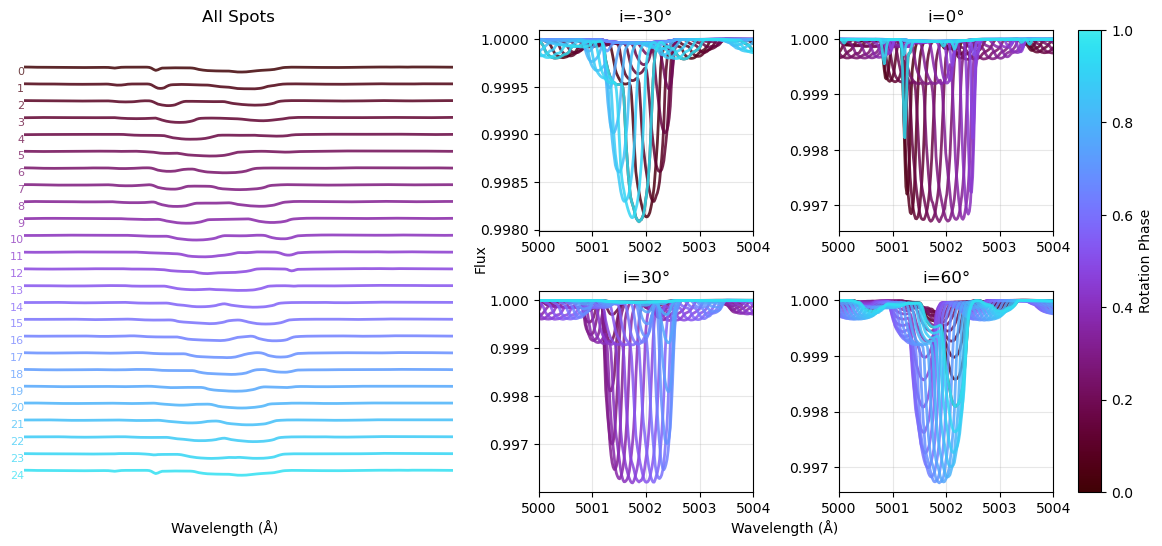

In [96]:
# Create figure with 5 subplots: 1 custom row-by-row on left, 4 smaller in 2x2 grid on right
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], hspace=0.3, wspace=0.3)

# Custom: create axis for the left "pane" (not used as a normal plot, but for manual phase rows)
ax_main = fig.add_subplot(gs[:, 0])
ax_main.axis('off')  # No axes or grid

# Four smaller subplots in 2x2 grid on the right (keep as before)
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

lim_start = 5000
lim_end = 5004
xticks = [5000, 5001, 5002, 5003, 5004]
linewidth=2

alpha=0.85

# Create colormap for phases
cmap = cmr.gem
colors = [cmap(i / len(spec)) for i in range(len(spec))]

# ---- Draw each phase row-by-row in left pane (no axes, no grid) ----
# Space out rows to fill vertical extent of ax_main
n = len(spec)
row_height = 1.0 / n  # leave margin top/bottom
y0 = 0.95  # top start
for i in range(n):
    y = y0 - i * row_height
    norm_flux = spec[i][:, 0] / spec[i][:, 1]
    # Vertically shift all curves so baseline = y
    # Rescale flux to a small vertical range (so each profile is visible but doesn't overlap)
    prof_scale = 0.3 * row_height  # controls how tall each line appears
    baseline = y
    offset_flux = baseline + (norm_flux - norm_flux.min()) * (prof_scale / (norm_flux.max() - norm_flux.min() + 1e-8))
    ax_main.plot(vws, offset_flux, color=colors[i], alpha=alpha, linewidth=linewidth)
    # Optionally: add a text label for phase # or index
    ax_main.text(lim_start, baseline, f"{i}", va='center', ha='right', fontsize=8, color=colors[i], alpha=0.75)
# Set left pane limits to keep lines in view
ax_main.set_xlim(lim_start, lim_end)
ax_main.set_ylim(-0.05, 1.05)

# ---- Right panels (unchanged) ----
for i in range(n):
    ax1.plot(vws, spec_min30[i][:, 0]/spec_min30[i][:, 1], alpha=alpha, color=colors[i], linewidth=linewidth)
    ax2.plot(vws, spec_0[i][:, 0]/spec_0[i][:, 1], alpha=alpha, color=colors[i], linewidth=linewidth)
    ax3.plot(vws, spec_30[i][:, 0]/spec_30[i][:, 1], alpha=alpha, color=colors[i], linewidth=linewidth)
    ax4.plot(vws, spec_60[i][:, 0]/spec_60[i][:, 1], alpha=alpha, color=colors[i], linewidth=linewidth)

# Add labels and formatting
fig.text(0.25, 0.05, 'Wavelength (Å)', ha='center', va='center')
# No y-label or title on ax_main (no axes)
ax_main.set_title('All Spots')
ax_main.set_xlim(lim_start, lim_end)

fig.text(0.6, 0.05, 'Wavelength (Å)', ha='center', va='center')
fig.text(0.41, 0.5, 'Flux', ha='center', va='center', rotation='vertical')

ax1.set_title('i=-30°')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(lim_start, lim_end)
ax1.set_xticks(xticks)

ax2.set_title('i=0°')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(lim_start, lim_end)
ax2.set_xticks(xticks)

ax3.set_title('i=30°')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(lim_start, lim_end)
ax3.set_xticks(xticks)

ax4.set_title('i=60°')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(lim_start, lim_end)
ax4.set_xticks(xticks)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_main, ax1, ax2, ax3, ax4], orientation='vertical', pad=0.02)
cbar.set_label('Rotation Phase')

plt.show()

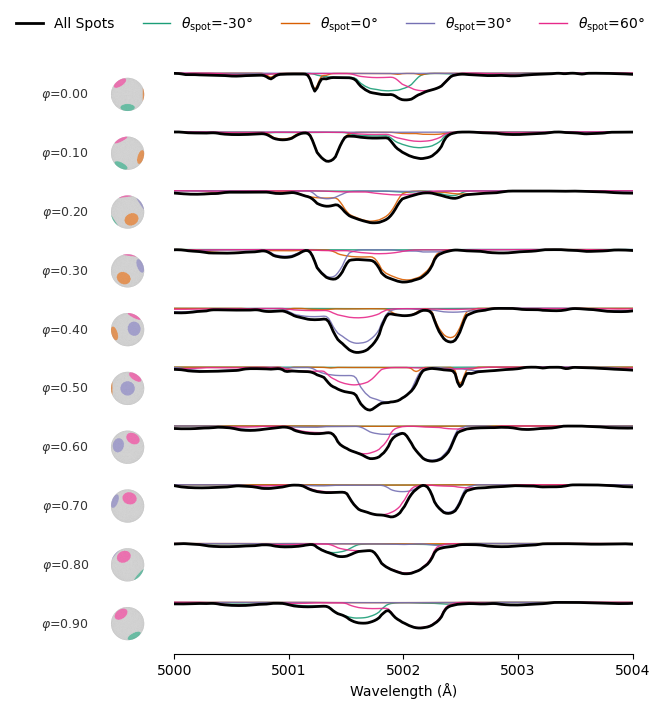

In [97]:
# Row-per-phase figure: combined spectrum in bold + individual spot contributions thinner
# plus a small 3D mesh inset on the left of each row showing what spots are
# visible at the corresponding rotation phase.
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import _mesh_center, _set_axes_centered

fig, ax = plt.subplots(figsize=(6.5, 7))
ax.axis('off')
# Leave room on the left for small 3D mesh insets
fig.subplots_adjust(left=0.26, right=0.965, top=0.90, bottom=0.06)

lim_start = 5000
lim_end = 5004

# Same spot colors as in the animation
spot_colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]
spot_labels = ['$\\theta_{\\rm{spot}}$=-30°', '$\\theta_{\\rm{spot}}$=0°', '$\\theta_{\\rm{spot}}$=30°', '$\\theta_{\\rm{spot}}$=60°']

n_phases = 10
# Evenly spaced phases over one full rotation [0, 1); excludes the redundant
# phase-1.0 frame that duplicates phase 0.0.
phase_indices = np.linspace(0, len(spec), n_phases, endpoint=False).astype(int)

spot_specs = [[spec_min30[k] for k in phase_indices],
              [spec_0[k] for k in phase_indices],
              [spec_30[k] for k in phase_indices],
              [spec_60[k] for k in phase_indices]]

combined_color = 'black'
combined_lw = 2.0
spot_lw = 1.0
spot_alpha = 0.9
combined_alpha = 1.0

spec_to_plot = [spec[k] for k in phase_indices]
mts_to_plot = [mts[k] for k in phase_indices]
n = len(spec_to_plot)

# Normalize once globally so rows (phases) are directly comparable and
# relative depths between combined and individual contributions are preserved.
all_curves = []
for i in range(n):
    all_curves.append(spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1])
    for sp in spot_specs:
        all_curves.append(sp[i][:, 0] / sp[i][:, 1])
all_curves = np.asarray(all_curves)
g_min = all_curves.min()
g_max = all_curves.max()
g_range = g_max - g_min + 1e-12

row_height = 1.0 / n
prof_scale = 0.75 * row_height
y0 = 1.0 - row_height / 2

def to_row(flux, baseline):
    return baseline + (flux - g_min) * (prof_scale / g_range) - prof_scale / 2

for i in range(n):
    baseline = y0 - i * row_height

    for sp, col in zip(spot_specs, spot_colors):
        flux = sp[i][:, 0] / sp[i][:, 1]
        ax.plot(vws, to_row(flux, baseline), color=col, alpha=spot_alpha,
                linewidth=spot_lw)

    combined = spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1]
    ax.plot(vws, to_row(combined, baseline), color=combined_color,
            alpha=combined_alpha, linewidth=combined_lw)


ax.set_xlim(lim_start, lim_end)
ax.set_ylim(0, 1)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=combined_color, linewidth=combined_lw, label='All Spots'),
] + [
    Line2D([0], [0], color=c, linewidth=spot_lw, label=lbl)
    for c, lbl in zip(spot_colors, spot_labels)
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, 0.99), bbox_transform=fig.transFigure,
          ncol=5, frameon=False)

ax_x = ax.twiny()
ax_x.set_xlim(lim_start, lim_end)
ax_x.xaxis.set_ticks_position('bottom')
ax_x.xaxis.set_label_position('bottom')
ax_x.spines['top'].set_visible(False)
ax_x.spines['left'].set_visible(False)
ax_x.spines['right'].set_visible(False)
ax_x.set_yticks([])
ax_x.set_xticks([5000, 5001, 5002, 5003, 5004])
ax_x.set_xlabel('Wavelength (Å)')

# --- 3D mesh insets on the left, one per phase row ---
# Color faces by their dominant spot so the 3D spots match the corresponding
# spectrum line colors. Face indices don't change under rotation, so we
# compute the per-face spot assignment once on the unrotated multi-spot mesh
# `ms` and reuse it for every phase.
from spice.models.spots import generate_spherical_spot

_spot_lats_deg = [-30, 0, 30, 60]
_spot_lons_deg = [-90, 0, 90, 180]
_spot_contribs = np.stack([
    np.asarray(generate_spherical_spot(
        ms.d_centers, ms.radius,
        lat_to_theta(lat), lon_to_phi(lon),
        SPOT_RADIUS, 1.0, 0.5,
    ))
    for lat, lon in zip(_spot_lats_deg, _spot_lons_deg)
], axis=1)  # (n_faces, n_spots)
_best_spot = np.argmax(_spot_contribs, axis=1)
_best_contrib = np.take_along_axis(
    _spot_contribs, _best_spot[:, None], axis=1
).squeeze(-1)
# Sigmoid half-value marks the nominal spot edge; weaker faces are unspotted.
_unspotted_mask = _best_contrib < 0.5
_spot_rgba = np.array([mpl.colors.to_rgba(c) for c in spot_colors])
_base_color = np.array(mpl.colors.to_rgba('0.75'))
_face_spot_colors = _spot_rgba[_best_spot]
_face_spot_colors[_unspotted_mask] = _base_color


def _los_view_angles(mesh):
    # Return matplotlib (elev, azim) in degrees such that the camera sits on
    # the OBSERVER side of the star, i.e. along -mesh.los_vector.
    # ``los_vector`` points from the observer toward the star (visible faces
    # have mus = -dot(normal, los) > 0), so aiming the camera along
    # +los_vector would view the observer-facing hemisphere from behind,
    # mirroring the disk left-right and flipping the apparent rotation sense.
    # Matplotlib's camera position is
    #   (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the observer direction -los gives:
    #   elev = arcsin(-los_z),   azim = arctan2(-los_y, -los_x).
    # With inclination_to_los_axis(i) = (0, sin i, -cos i), an inclination of
    # e.g. 60 deg yields elev = +30 deg, azim = -90 deg, i.e. the star is
    # viewed 30 deg above the equator, matching what the observer sees.
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    observer = -los
    elev = float(np.degrees(np.arcsin(np.clip(observer[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(observer[1], observer[0])))
    return elev, azim


ax_pos = ax.get_position()
inset_h = 0.95 * row_height * ax_pos.height
# Keep insets square in inches by compensating for figure aspect ratio.
inset_w = inset_h * fig.get_figheight() / fig.get_figwidth()
inset_right = ax_pos.x0 - 0.03  # small gap between inset and spectrum
inset_left = max(0.005, inset_right - inset_w)

for i, mesh in enumerate(mts_to_plot):
    baseline = y0 - i * row_height
    fig_y = ax_pos.y0 + baseline * ax_pos.height
    # Phase label to the left of the sphere inset (avoids overlapping it).
    fig.text(inset_left - 0.015, fig_y, f"$\\varphi$={i / n:.2f}",
             ha='right', va='center', fontsize=9, color='0.2')
    inset_ax = fig.add_axes(
        [inset_left, fig_y - inset_h / 2, inset_w, inset_h],
        projection='3d',
    )
    inset_ax.set_axis_off()
    # Orthographic projection so the inclination isn't distorted by the default
    # matplotlib perspective at small inset sizes.
    inset_ax.set_proj_type('ortho')
    inset_ax.patch.set_alpha(0.0)

    # Hide non-visible faces so only the observer-facing hemisphere is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = _face_spot_colors.copy()
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    p = art3d.Poly3DCollection(
        mesh.mesh_elements,
        facecolors=face_colors,
        edgecolor='none',
        linewidths=0,
    )
    inset_ax.add_collection(p)

    center = _mesh_center(mesh)
    _set_axes_centered(inset_ax, center, 1.0 * float(mesh.radius))
    inset_ax.set_box_aspect((1, 1, 1))
    # Apply the LOS-derived view AFTER the box aspect / limits so it isn't
    # overwritten by later autoscale decisions.
    elev, azim = _los_view_angles(mesh)
    inset_ax.view_init(elev=elev, azim=azim)

plt.show()


TODO: color spots

In [98]:
# Save the figure as PDF
fig.savefig('kochukov2017_spectra_comparison_nlte.pdf', bbox_inches='tight', dpi=300)
print("Figure saved to kochukov2017_spectra_comparison.pdf")

Figure saved to kochukov2017_spectra_comparison.pdf


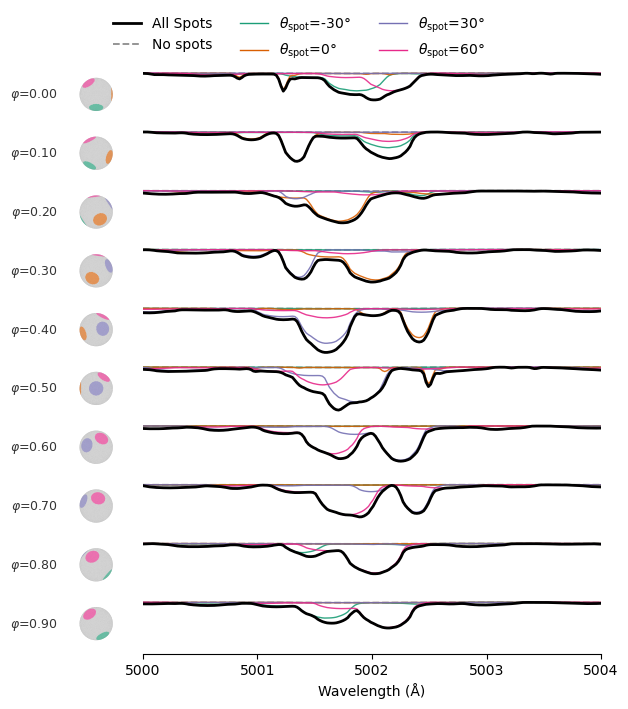

In [99]:
# COPY of the row-per-phase figure that ALSO overplots the spot-free,
# rotationally broadened photospheric profile ([Fe/H] = -4.0, no spots) as a
# grey dashed reference on every row, so the spot dips are seen superimposed on
# the underlying photospheric line. Otherwise identical to the figure above.
# Combined spectrum in bold + individual spot contributions thinner
# plus a small 3D mesh inset on the left of each row showing what spots are
# visible at the corresponding rotation phase.
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import _mesh_center, _set_axes_centered

fig, ax = plt.subplots(figsize=(6.5, 7))
ax.axis('off')
# Leave room on the left for small 3D mesh insets
fig.subplots_adjust(left=0.26, right=0.965, top=0.90, bottom=0.06)

lim_start = 5000
lim_end = 5004

# Same spot colors as in the animation
spot_colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]
spot_labels = ['$\\theta_{\\rm{spot}}$=-30°', '$\\theta_{\\rm{spot}}$=0°', '$\\theta_{\\rm{spot}}$=30°', '$\\theta_{\\rm{spot}}$=60°']

n_phases = 10
# Evenly spaced phases over one full rotation [0, 1); excludes the redundant
# phase-1.0 frame that duplicates phase 0.0.
phase_indices = np.linspace(0, len(spec), n_phases, endpoint=False).astype(int)

spot_specs = [[spec_min30[k] for k in phase_indices],
              [spec_0[k] for k in phase_indices],
              [spec_30[k] for k in phase_indices],
              [spec_60[k] for k in phase_indices]]

combined_color = 'black'
combined_lw = 2.0
spot_lw = 1.0
spot_alpha = 0.9
combined_alpha = 1.0

# Spot-free rotationally broadened photosphere ([Fe/H] = -4.0). It is
# axisymmetric, hence phase-independent, so the same reference curve is drawn on
# every row beneath the spotted profiles (from cell that defines
# rotated_no_spots_flux).
photosphere = np.asarray(rotated_no_spots_flux)
photosphere_norm = photosphere[:, 0] / photosphere[:, 1]
photosphere_color = '0.55'
photosphere_lw = 1.3

spec_to_plot = [spec[k] for k in phase_indices]
mts_to_plot = [mts[k] for k in phase_indices]
n = len(spec_to_plot)

# Normalize once globally so rows (phases) are directly comparable and
# relative depths between combined and individual contributions are preserved.
all_curves = []
for i in range(n):
    all_curves.append(spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1])
    for sp in spot_specs:
        all_curves.append(sp[i][:, 0] / sp[i][:, 1])
all_curves.append(photosphere_norm)
all_curves = np.asarray(all_curves)
g_min = all_curves.min()
g_max = all_curves.max()
g_range = g_max - g_min + 1e-12

row_height = 1.0 / n
prof_scale = 0.75 * row_height
y0 = 1.0 - row_height / 2

def to_row(flux, baseline):
    return baseline + (flux - g_min) * (prof_scale / g_range) - prof_scale / 2

for i in range(n):
    baseline = y0 - i * row_height

    for sp, col in zip(spot_specs, spot_colors):
        flux = sp[i][:, 0] / sp[i][:, 1]
        ax.plot(vws, to_row(flux, baseline), color=col, alpha=spot_alpha,
                linewidth=spot_lw)

    # Photospheric (no-spot) reference, identical on every row.
    ax.plot(vws, to_row(photosphere_norm, baseline), color=photosphere_color,
            linestyle='--', linewidth=photosphere_lw, alpha=0.9, zorder=1)

    combined = spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1]
    ax.plot(vws, to_row(combined, baseline), color=combined_color,
            alpha=combined_alpha, linewidth=combined_lw)


ax.set_xlim(lim_start, lim_end)
ax.set_ylim(0, 1)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=combined_color, linewidth=combined_lw, label='All Spots'),
    Line2D([0], [0], color=photosphere_color, linewidth=photosphere_lw,
           linestyle='--', label='No spots'),
] + [
    Line2D([0], [0], color=c, linewidth=spot_lw, label=lbl)
    for c, lbl in zip(spot_colors, spot_labels)
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, 0.99), bbox_transform=fig.transFigure,
          ncol=3, frameon=False)

ax_x = ax.twiny()
ax_x.set_xlim(lim_start, lim_end)
ax_x.xaxis.set_ticks_position('bottom')
ax_x.xaxis.set_label_position('bottom')
ax_x.spines['top'].set_visible(False)
ax_x.spines['left'].set_visible(False)
ax_x.spines['right'].set_visible(False)
ax_x.set_yticks([])
ax_x.set_xticks([5000, 5001, 5002, 5003, 5004])
ax_x.set_xlabel('Wavelength (Å)')

# --- 3D mesh insets on the left, one per phase row ---
# Color faces by their dominant spot so the 3D spots match the corresponding
# spectrum line colors. Face indices don't change under rotation, so we
# compute the per-face spot assignment once on the unrotated multi-spot mesh
# `ms` and reuse it for every phase.
from spice.models.spots import generate_spherical_spot

_spot_lats_deg = [-30, 0, 30, 60]
_spot_lons_deg = [-90, 0, 90, 180]
_spot_contribs = np.stack([
    np.asarray(generate_spherical_spot(
        ms.d_centers, ms.radius,
        lat_to_theta(lat), lon_to_phi(lon),
        SPOT_RADIUS, 1.0, 0.5,
    ))
    for lat, lon in zip(_spot_lats_deg, _spot_lons_deg)
], axis=1)  # (n_faces, n_spots)
_best_spot = np.argmax(_spot_contribs, axis=1)
_best_contrib = np.take_along_axis(
    _spot_contribs, _best_spot[:, None], axis=1
).squeeze(-1)
# Sigmoid half-value marks the nominal spot edge; weaker faces are unspotted.
_unspotted_mask = _best_contrib < 0.5
_spot_rgba = np.array([mpl.colors.to_rgba(c) for c in spot_colors])
_base_color = np.array(mpl.colors.to_rgba('0.75'))
_face_spot_colors = _spot_rgba[_best_spot]
_face_spot_colors[_unspotted_mask] = _base_color


def _los_view_angles(mesh):
    # Return matplotlib (elev, azim) in degrees such that the camera sits on
    # the OBSERVER side of the star, i.e. along -mesh.los_vector.
    # ``los_vector`` points from the observer toward the star (visible faces
    # have mus = -dot(normal, los) > 0), so aiming the camera along
    # +los_vector would view the observer-facing hemisphere from behind,
    # mirroring the disk left-right and flipping the apparent rotation sense.
    # Matplotlib's camera position is
    #   (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the observer direction -los gives:
    #   elev = arcsin(-los_z),   azim = arctan2(-los_y, -los_x).
    # With inclination_to_los_axis(i) = (0, sin i, -cos i), an inclination of
    # e.g. 60 deg yields elev = +30 deg, azim = -90 deg, i.e. the star is
    # viewed 30 deg above the equator, matching what the observer sees.
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    observer = -los
    elev = float(np.degrees(np.arcsin(np.clip(observer[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(observer[1], observer[0])))
    return elev, azim


ax_pos = ax.get_position()
inset_h = 0.95 * row_height * ax_pos.height
# Keep insets square in inches by compensating for figure aspect ratio.
inset_w = inset_h * fig.get_figheight() / fig.get_figwidth()
inset_right = ax_pos.x0 - 0.03  # small gap between inset and spectrum
inset_left = max(0.005, inset_right - inset_w)

for i, mesh in enumerate(mts_to_plot):
    baseline = y0 - i * row_height
    fig_y = ax_pos.y0 + baseline * ax_pos.height
    # Phase label to the left of the sphere inset (avoids overlapping it).
    fig.text(inset_left - 0.015, fig_y, f"$\\varphi$={i / n:.2f}",
             ha='right', va='center', fontsize=9, color='0.2')
    inset_ax = fig.add_axes(
        [inset_left, fig_y - inset_h / 2, inset_w, inset_h],
        projection='3d',
    )
    inset_ax.set_axis_off()
    # Orthographic projection so the inclination isn't distorted by the default
    # matplotlib perspective at small inset sizes.
    inset_ax.set_proj_type('ortho')
    inset_ax.patch.set_alpha(0.0)

    # Hide non-visible faces so only the observer-facing hemisphere is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = _face_spot_colors.copy()
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    p = art3d.Poly3DCollection(
        mesh.mesh_elements,
        facecolors=face_colors,
        edgecolor='none',
        linewidths=0,
    )
    inset_ax.add_collection(p)

    center = _mesh_center(mesh)
    _set_axes_centered(inset_ax, center, 1.0 * float(mesh.radius))
    inset_ax.set_box_aspect((1, 1, 1))
    # Apply the LOS-derived view AFTER the box aspect / limits so it isn't
    # overwritten by later autoscale decisions.
    elev, azim = _los_view_angles(mesh)
    inset_ax.view_init(elev=elev, azim=azim)

fig.savefig('kochukov2017_spectra_comparison_with_photosphere.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


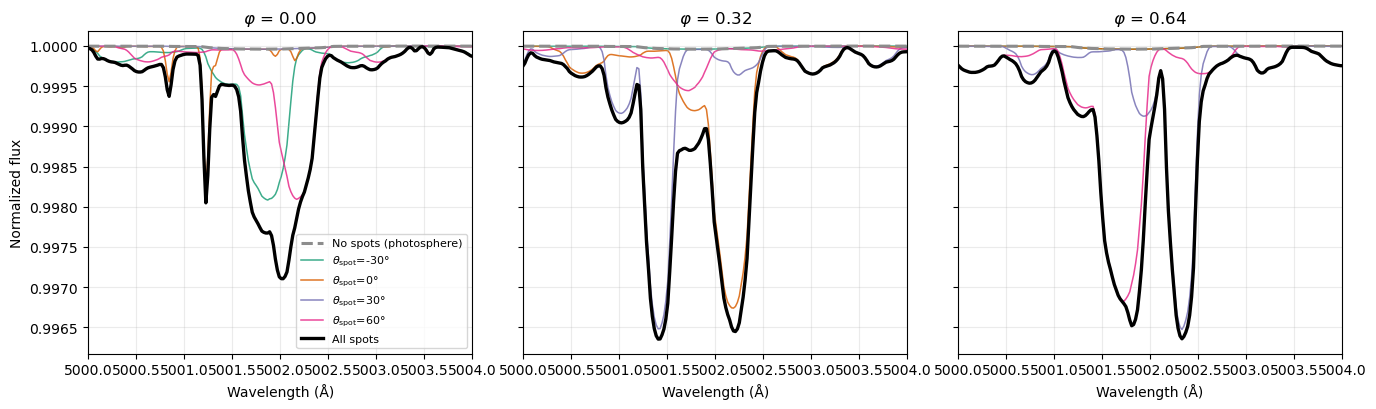

In [103]:
# Full-scale, single-panel comparisons (NOT vertically stacked/compressed like the
# row-per-phase figure) at a few representative phases. Each panel uses a true
# normalized-flux axis so the actual line depths are visible, making clear that
# the spot-free photospheric profile ([Fe/H] = -4.0, grey dashed) is a
# non-negligible contribution on top of which the spot dips are superimposed.
photosphere_norm = np.asarray(rotated_no_spots_flux)[:, 0] / np.asarray(rotated_no_spots_flux)[:, 1]

spot_colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]
spot_labels = ['$\\theta_{\\rm{spot}}$=-30°', '$\\theta_{\\rm{spot}}$=0°',
               '$\\theta_{\\rm{spot}}$=30°', '$\\theta_{\\rm{spot}}$=60°']
single_spot_specs = [spec_min30, spec_0, spec_30, spec_60]

n_tot = len(spec)
sel_phase_indices = [0, n_tot // 3, (2 * n_tot) // 3]

fig, axes = plt.subplots(1, len(sel_phase_indices),
                         figsize=(4.6 * len(sel_phase_indices), 4.2),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, k in zip(axes, sel_phase_indices):
    # Spot-free photosphere reference (phase-independent).
    ax.plot(vws, photosphere_norm, color='0.55', linestyle='--', linewidth=2.2,
            label='No spots (photosphere)', zorder=2)
    # Individual spot contributions.
    for sp, c, lbl in zip(single_spot_specs, spot_colors, spot_labels):
        ax.plot(vws, sp[k][:, 0] / sp[k][:, 1], color=c, linewidth=1.1,
                alpha=0.85, label=lbl, zorder=1)
    # Combined (all spots) profile.
    ax.plot(vws, spec[k][:, 0] / spec[k][:, 1], color='black', linewidth=2.4,
            label='All spots', zorder=3)

    ax.set_title(f"$\\varphi$ = {k / n_tot:.2f}")
    ax.set_xlabel('Wavelength (Å)')
    ax.set_xlim(5000, 5004)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Normalized flux')
axes[0].legend(loc='lower right', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig('kochukov2017_photosphere_vs_spots.pdf', bbox_inches='tight', dpi=300)
plt.show()


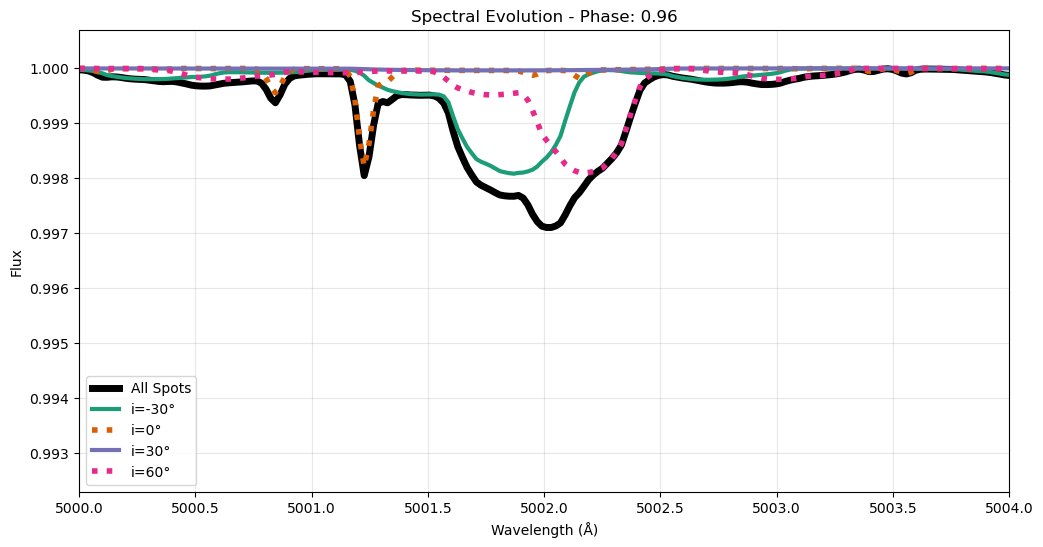

In [100]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create figure for animation
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]

# Initialize empty lines for each inclination
line_main, = ax.plot([], [], color='black', label='All Spots', linewidth=5)
line_min30, = ax.plot([], [], color=colors[0], label='i=-30°', linewidth=3)
line_0, = ax.plot([], [], color=colors[1], label='i=0°', linewidth=4, linestyle='dotted')
line_30, = ax.plot([], [], color=colors[2], label='i=30°', linewidth=3)
line_60, = ax.plot([], [], color=colors[3], label='i=60°', linewidth=4, linestyle='dotted')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_title('Spectral Evolution - Phase: 0.00')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Set axis limits based on data
ax.set_xlim(vws[0], vws[-1])
all_specs = spec + spec_min30 + spec_0 + spec_30 + spec_60
y_min = 0.993
y_max = 1.
y_range = y_max - y_min
ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)
ax.set_xlim(5000, 5004)

def init():
    line_main.set_data([], [])
    line_min30.set_data([], [])
    line_0.set_data([], [])
    line_30.set_data([], [])
    line_60.set_data([], [])
    return line_main, line_min30, line_0, line_30, line_60

def animate(frame):
    line_main.set_data(vws, spec[frame][:, 0]/spec[frame][:, 1])
    line_min30.set_data(vws, spec_min30[frame][:, 0]/spec_min30[frame][:, 1])
    line_0.set_data(vws, spec_0[frame][:, 0]/spec_0[frame][:, 1])
    line_30.set_data(vws, spec_30[frame][:, 0]/spec_30[frame][:, 1])
    line_60.set_data(vws, spec_60[frame][:, 0]/spec_60[frame][:, 1])
    
    # Update title with current phase
    phase = frame / len(spec)
    ax.set_title(f'Spectral Evolution - Phase: {phase:.2f}')
    
    return line_main, line_min30, line_0, line_30, line_60

# Create animation
anim = FuncAnimation(fig, animate, init_func=init, frames=len(spec), 
                     interval=200, blit=True, repeat=True)

# Display animation in notebook
HTML(anim.to_jshtml())

In [101]:
# Save animation to file
anim.save('spectral_evolution.gif', writer='pillow', fps=5, dpi=100)
print("Animation saved to spectral_evolution.gif")

Animation saved to spectral_evolution.gif


NameError: name 'spec_nlte' is not defined

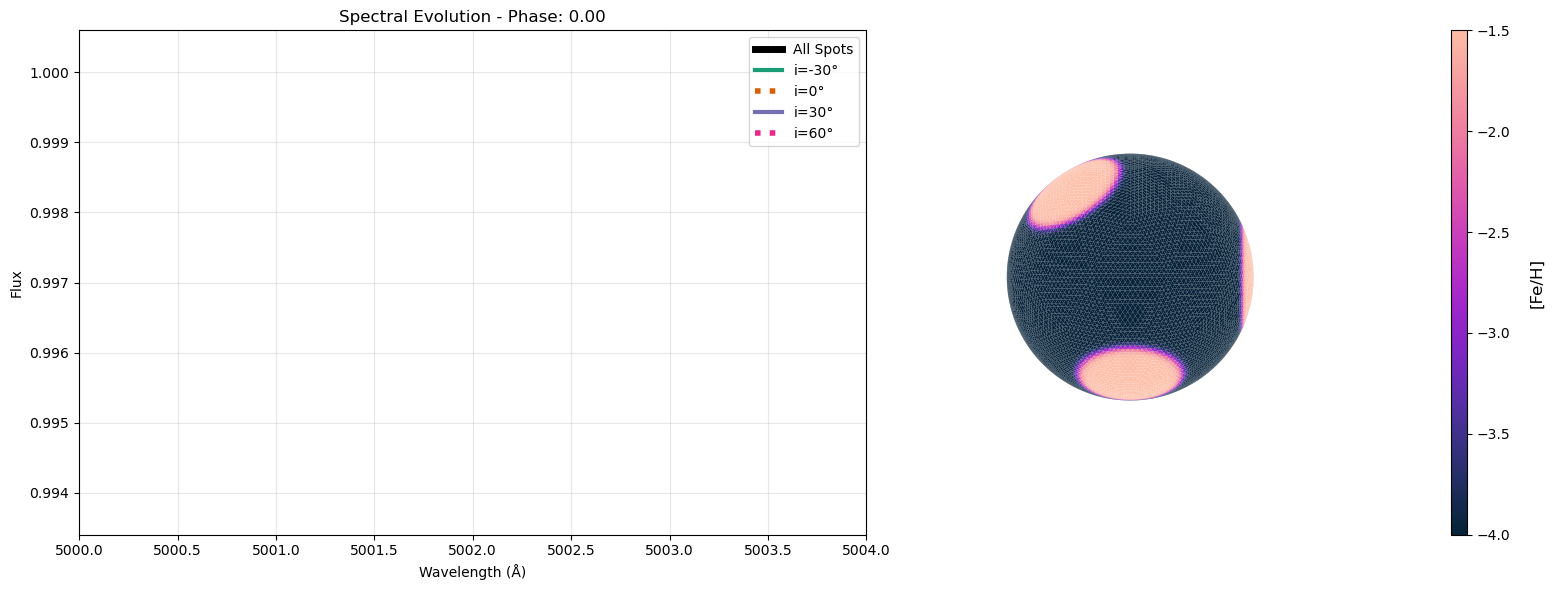

In [102]:
from spice.plots.plot_mesh import *
import numpy as np

def _evaluate_to_be_mapped_property(mesh,
                                    property = DEFAULT_PROPERTY,
                                    property_label = None):
    """
    Evaluate the property to be mapped in visualization.
    (Implementation unchanged)
    """
    if isinstance(property, str):
        if property in DEFAULT_PLOT_PROPERTY_LABELS:
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = DEFAULT_PLOT_PROPERTY_LABELS[property]
        elif hasattr(mesh, property):
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = property
        else:
            raise ValueError(f'Invalid property {property} - must be an attribute of MeshModel or one of {list(DEFAULT_PLOT_PROPERTY_LABELS.keys())}')
    elif isinstance(property, int):
        if property > mesh.parameters.shape[-1]-1:
            raise ValueError(f'Invalid property index {property} - must be smaller than {mesh.parameters.shape[-1]}')
        to_be_mapped = mesh.parameters[:, property]
        if property_label is None:
            property_label = ''
    else:
        raise ValueError(f"Property must be either of type str or int")
    return to_be_mapped, property_label

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

colors = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A"]

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 4, width_ratios=[3., 1.55, 0.05, 0.06])

# SPECTRUM: Left panel
ax_spec = fig.add_subplot(gs[0])
ax_spec.set_xlabel('Wavelength (Å)')
ax_spec.set_ylabel('Flux')
ax_spec.set_title('Spectral Evolution - Phase: 0.00')

line_main, = ax_spec.plot([], [], color='black', label='All Spots', linewidth=5)
line_min30, = ax_spec.plot([], [], color=colors[0], label='i=-30°', linewidth=3)
line_0, = ax_spec.plot([], [], color=colors[1], label='i=0°', linewidth=4, linestyle='dotted')
line_30, = ax_spec.plot([], [], color=colors[2], label='i=30°', linewidth=3)
line_60, = ax_spec.plot([], [], color=colors[3], label='i=60°', linewidth=4, linestyle='dotted')

spec_legend = ax_spec.legend(loc='best')
ax_spec.grid(True, alpha=0.3)
ax_spec.set_xlim(5000, 5004)
y_min = 0.994
y_max = 1.
y_range = y_max - y_min
ax_spec.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

plt.tight_layout(rect=[0, 0, 0.94, 1])

# ---- Observed-surface 3D panel (orthographic, camera along LOS, no axes) ----
ax_star = fig.add_subplot(gs[1], projection='3d')
# Expand the 3D axes bbox to remove the default padding that
# matplotlib reserves for axis labels/ticks in 3D projections.
_star_pos = ax_star.get_position()
ax_star.set_position([
    _star_pos.x0 - 0.06 * _star_pos.width,
    _star_pos.y0 - 0.18 * _star_pos.height,
    _star_pos.width * 1.35,
    _star_pos.height * 1.35,
])

mesh0 = mts[0]
property_label = '[Fe/H]'
to_be_mapped_0, cbar_label = _evaluate_to_be_mapped_property(mesh0, 2, property_label)
cmap = DEFAULT_PROPERTY_CMAPS.get(2, DEFAULT_CMAP)
vmin = np.min([_evaluate_to_be_mapped_property(m, 2, property_label)[0].min() for m in mts])
vmax = np.max([_evaluate_to_be_mapped_property(m, 2, property_label)[0].max() for m in mts])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

ax_spacer = fig.add_subplot(gs[2])
ax_spacer.axis('off')

cbar_ax = fig.add_subplot(gs[3])
mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, cax=cbar_ax)
cbar.set_label(cbar_label, fontsize=12, labelpad=14)
cbar_ax.tick_params(axis='y', labelsize=10, colors='black')

fig.subplots_adjust(right=0.92, wspace=0.18)


def _los_view_angles(mesh):
    # Camera on the OBSERVER side: mesh.los_vector points observer -> star,
    # so the camera position must lie along -los_vector (viewing along
    # +los_vector from behind mirrors the disk left-right and flips the
    # apparent rotation sense). Matplotlib camera position for (elev, azim) is
    # (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)); solving for -los:
    #   elev = arcsin(-los_z),  azim = arctan2(-los_y, -los_x).
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    observer = -los
    elev = float(np.degrees(np.arcsin(np.clip(observer[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(observer[1], observer[0])))
    return elev, azim


def _draw_observed_surface(frame):
    ax_star.cla()
    ax_star.set_axis_off()
    # Orthographic projection so the observed disk isn't distorted.
    ax_star.set_proj_type('ortho')
    ax_star.patch.set_alpha(0.0)

    mesh = mts[frame]
    to_be_mapped, _ = _evaluate_to_be_mapped_property(mesh, 2, property_label)

    center_array = np.asarray(mesh.center)
    radius_scalar = float(np.asarray(mesh.radius))
    if center_array.ndim == 0:
        cx = cy = cz = float(center_array)
    else:
        cx = float(center_array[0])
        cy = float(center_array[1])
        cz = float(center_array[2])
    axes_lim = 0.98 * radius_scalar
    ax_star.set_xlim3d(cx - axes_lim, cx + axes_lim)
    ax_star.set_ylim3d(cy - axes_lim, cy + axes_lim)
    ax_star.set_zlim3d(cz - axes_lim, cz + axes_lim)
    ax_star.set_box_aspect((1, 1, 1))

    # Hide the back hemisphere so only the observer-facing surface is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = mpl.colormaps[cmap](norm(to_be_mapped))
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    vs2 = mesh.vertices[mesh.faces.astype(int)]
    mesh_collection = art3d.Poly3DCollection(
        vs2, facecolors=face_colors, edgecolor='none', linewidths=0,
    )
    ax_star.add_collection(mesh_collection)

    elev, azim = _los_view_angles(mesh)
    ax_star.view_init(elev=elev, azim=azim)


def init_combined():
    line_main.set_data([], [])
    line_min30.set_data([], [])
    line_0.set_data([], [])
    line_30.set_data([], [])
    line_60.set_data([], [])
    _draw_observed_surface(0)
    return line_main, line_min30, line_0, line_30, line_60


def animate_combined(frame):
    line_main.set_data(vws, spec_nlte[frame][:, 0]/spec_nlte[frame][:, 1])
    line_min30.set_data(vws, spec_min30_nlte[frame][:, 0]/spec_min30_nlte[frame][:, 1])
    line_0.set_data(vws, spec_0_nlte[frame][:, 0]/spec_0_nlte[frame][:, 1])
    line_30.set_data(vws, spec_30_nlte[frame][:, 0]/spec_30_nlte[frame][:, 1])
    line_60.set_data(vws, spec_60_nlte[frame][:, 0]/spec_60_nlte[frame][:, 1])
    phase = frame / len(spec)
    ax_spec.set_title(f'Spectral Evolution - Phase: {phase:.2f}')
    _draw_observed_surface(frame)
    return line_main, line_min30, line_0, line_30, line_60


anim_combined = FuncAnimation(fig, animate_combined, init_func=init_combined,
                              frames=len(spec), interval=200, blit=True, repeat=True)

HTML(anim_combined.to_jshtml())


In [ ]:
anim_combined.save('spectral_evolution_w_model.gif', writer='pillow', fps=5, dpi=100)